# Context-Aware Chatbot Using RAG

## Objective
Build a conversational chatbot that:
- remembers prior turns,
- retrieves relevant information from a vectorized knowledge base,
- generates grounded answers,
- and includes a Streamlit deployment script.

This notebook is self-contained and uses a custom support-style corpus so it can run on Kaggle without external files.

## Notebook Roadmap
1. Build a custom knowledge base  
2. Inspect and visualize the corpus  
3. Chunk documents and create a vector store  
4. Retrieve relevant context  
5. Generate answers with memory  
6. Test multi-turn conversations  
7. Evaluate retrieval quality  
8. Save artifacts and create a Streamlit app  
9. Final summary

In [29]:
!rm -rf /kaggle/working/*


In [30]:
# Optional installs if needed in Kaggle
# !pip -q install transformers joblib streamlit

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, set_seed

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [31]:
# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = "google/flan-t5-small"
MAX_LENGTH = 512
MAX_NEW_TOKENS = 128
TOP_K_CONTEXT = 3
MEMORY_TURNS = 4

OUTPUT_DIR = Path("/kaggle/working/context_aware_rag_chatbot")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Output dir:", OUTPUT_DIR)

Model: google/flan-t5-small
Output dir: /kaggle/working/context_aware_rag_chatbot


## Step 1: Build a Custom Knowledge Base
A small support-style corpus keeps the notebook lightweight and reproducible.

In [32]:
# ============================================================
# CUSTOM KNOWLEDGE BASE
# ============================================================

kb_docs = [
    {
        "doc_id": 1,
        "topic": "Account Access",
        "title": "Password Reset and Login Lockouts",
        "content": "Users can reset their password from the sign-in page by clicking Forgot password. A reset link is emailed to the registered address and expires after 30 minutes. Accounts lock after 5 failed login attempts and unlock automatically after 15 minutes. If the email address is no longer accessible, users must contact support with proof of ownership."
    },
    {
        "doc_id": 2,
        "topic": "Billing",
        "title": "Invoices, Charges, and Refunds",
        "content": "Invoices are generated at the beginning of each billing cycle and can be downloaded from the billing page. If a customer sees a duplicate charge, the billing team should be contacted with the transaction ID. Refunds are usually processed within 5 to 10 business days after approval."
    },
    {
        "doc_id": 3,
        "topic": "Subscriptions",
        "title": "Plans, Upgrades, and Cancellations",
        "content": "The platform offers Basic, Pro, and Enterprise plans. Upgrades take effect immediately, while downgrades are applied at the end of the current billing cycle. Monthly plans can be canceled at any time from account settings. Annual plans are refundable only under the early cancellation policy."
    },
    {
        "doc_id": 4,
        "topic": "App Issues",
        "title": "Crashes, Performance, and Compatibility",
        "content": "If the mobile app crashes, users should first clear the app cache, update to the latest version, and restart the device. Performance issues are often caused by low memory, outdated operating systems, or unstable network connections. The app supports the two latest major versions of Android and iOS."
    },
    {
        "doc_id": 5,
        "topic": "API",
        "title": "API Keys, Rate Limits, and Errors",
        "content": "API keys can be created from the developer portal and should be stored securely. The default rate limit is 100 requests per minute for standard accounts. A 401 response usually means the API key is missing or invalid. A 429 response means the rate limit has been exceeded and the client should retry with backoff."
    },
    {
        "doc_id": 6,
        "topic": "Security",
        "title": "Privacy, Encryption, and Data Retention",
        "content": "All customer data is encrypted at rest and in transit. The platform follows role-based access control and logs administrative actions for audit purposes. Data retention for deleted workspaces is 30 days unless a legal hold is active. Enterprise customers can request single sign-on, IP allowlists, and enhanced audit logs."
    },
    {
        "doc_id": 7,
        "topic": "Notifications",
        "title": "Email and Push Notification Settings",
        "content": "Users can enable or disable product emails from notification preferences. Daily digest emails are sent at 8:00 AM local time if enabled. Push notifications require a supported mobile device and app permissions. If a user is not receiving emails, they should check spam filters and verify the sender address is approved."
    },
    {
        "doc_id": 8,
        "topic": "Integrations",
        "title": "Slack, Webhooks, and Third-Party Tools",
        "content": "Slack integration supports workspace-level notifications and channel mapping. Webhooks send event payloads as JSON to a user-provided endpoint. If webhook delivery fails, the system retries three times before pausing the integration. Third-party tools may require a workspace admin to authorize the connection."
    },
    {
        "doc_id": 9,
        "topic": "Data Export",
        "title": "Exports, Backups, and Importing Data",
        "content": "Users can export project data as CSV or JSON from the settings menu. Large exports may be delivered by email once processing completes. Backups are performed nightly and retained for 14 days. Imported files must follow the platform schema, otherwise rows are skipped and reported in the import log."
    },
    {
        "doc_id": 10,
        "topic": "Support",
        "title": "Escalation Paths and Response Times",
        "content": "Support tickets are categorized by severity from low to critical. Critical incidents receive the fastest response and may require a live incident bridge. Standard support responds within one business day. Customers should include screenshots, timestamps, and the exact error message for faster investigation."
    }
]

kb_df = pd.DataFrame(kb_docs)
kb_df["full_text"] = kb_df["title"] + ". " + kb_df["content"]
kb_df["word_count"] = kb_df["full_text"].str.split().apply(len)
kb_df["char_count"] = kb_df["full_text"].str.len()

display(kb_df[["doc_id", "topic", "title", "word_count"]])

,doc_id,topic,title,word_count
0,1,Account Access,Password Reset and Login Lockouts,61
1,2,Billing,"Invoices, Charges, and Refunds",51
2,3,Subscriptions,"Plans, Upgrades, and Cancellations",49
3,4,App Issues,"Crashes, Performance, and Compatibility",52
4,5,API,"API Keys, Rate Limits, and Errors",61
5,6,Security,"Privacy, Encryption, and Data Retention",54
6,7,Notifications,Email and Push Notification Settings,56
7,8,Integrations,"Slack, Webhooks, and Third-Party Tools",47
8,9,Data Export,"Exports, Backups, and Importing Data",54
9,10,Support,Escalation Paths and Response Times,48


## Step 2: Corpus Exploration and Visualizations
These charts help verify the corpus structure and document length distribution.

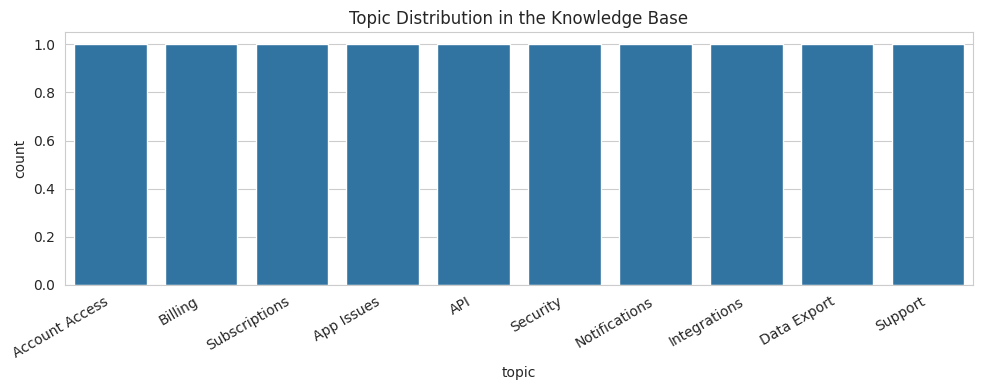

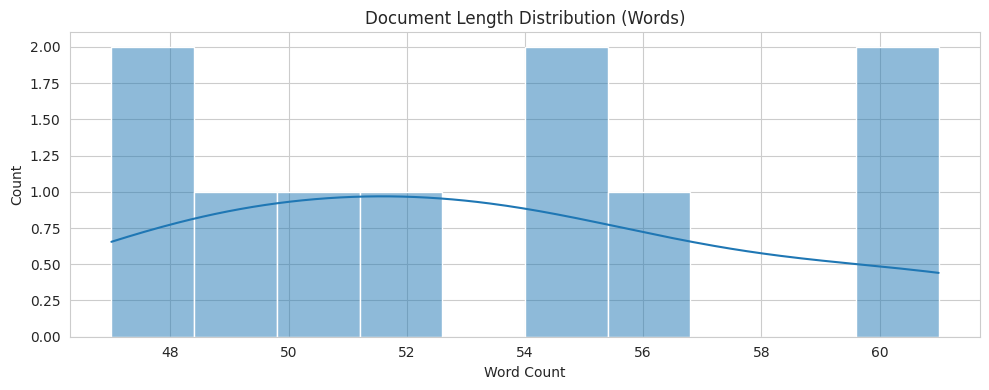

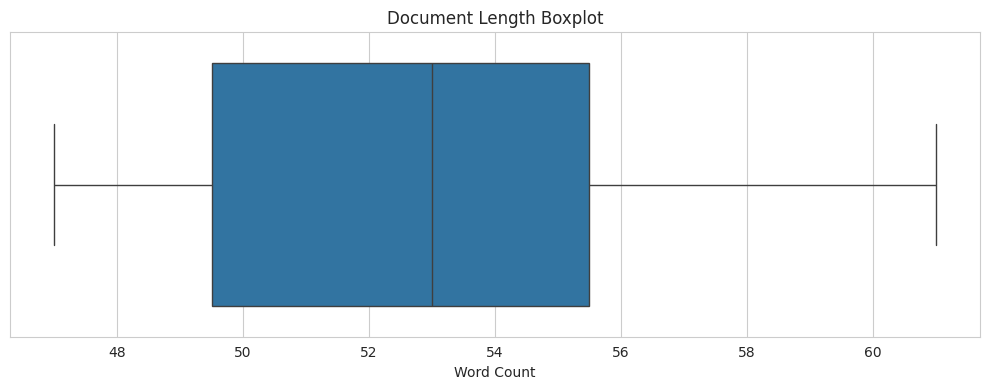

In [33]:
plt.figure(figsize=(10, 4))
sns.countplot(data=kb_df, x="topic", order=kb_df["topic"].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("Topic Distribution in the Knowledge Base")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(kb_df["word_count"], bins=10, kde=True)
plt.title("Document Length Distribution (Words)")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=kb_df["word_count"])
plt.title("Document Length Boxplot")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()

## Step 3: Chunking
We split documents into smaller chunks so retrieval works better.

In [34]:
def chunk_text(text, chunk_size=80, overlap=15):
    words = text.split()
    if len(words) <= chunk_size:
        return [text.strip()]
    chunks = []
    start = 0
    while start < len(words):
        end = min(len(words), start + chunk_size)
        chunk = " ".join(words[start:end]).strip()
        if chunk:
            chunks.append(chunk)
        if end == len(words):
            break
        start = max(0, end - overlap)
    return chunks

chunk_rows = []
for _, row in kb_df.iterrows():
    chunks = chunk_text(row["full_text"], chunk_size=80, overlap=15)
    for i, ch in enumerate(chunks, start=1):
        chunk_rows.append({
            "doc_id": row["doc_id"],
            "topic": row["topic"],
            "title": row["title"],
            "chunk_id": f"{row['doc_id']}_{i}",
            "chunk_text": ch
        })

chunks_df = pd.DataFrame(chunk_rows)
print("Total chunks:", len(chunks_df))
display(chunks_df.head())

Total chunks: 10


,doc_id,topic,title,chunk_id,chunk_text
0,1,Account Access,Password Reset and Login Lockouts,1_1,Password Reset and Login Lockouts. Users can r...
1,2,Billing,"Invoices, Charges, and Refunds",2_1,"Invoices, Charges, and Refunds. Invoices are g..."
2,3,Subscriptions,"Plans, Upgrades, and Cancellations",3_1,"Plans, Upgrades, and Cancellations. The platfo..."
3,4,App Issues,"Crashes, Performance, and Compatibility",4_1,"Crashes, Performance, and Compatibility. If th..."
4,5,API,"API Keys, Rate Limits, and Errors",5_1,"API Keys, Rate Limits, and Errors. API keys ca..."


## Step 4: Vector Store Creation
A lightweight TF-IDF representation acts as our vector store for retrieval.

In [35]:
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
doc_matrix = vectorizer.fit_transform(chunks_df["chunk_text"])

print("Vector matrix shape:", doc_matrix.shape)

Vector matrix shape: (10, 580)


## Step 5: Retrieval and Conversation Memory
We preserve recent dialogue turns and retrieve the most relevant chunks for each query.

In [36]:
conversation_history = []

MIN_SIMILARITY = 0.15
ABSTAIN_MESSAGE = "I could not find that information in the knowledge base."

def format_history(history, max_turns=MEMORY_TURNS):
    if not history:
        return "No prior context."
    recent = history[-2 * max_turns:]
    lines = []
    for msg in recent:
        role = "User" if msg["role"] == "user" else "Assistant"
        lines.append(f"{role}: {msg['content']}")
    return "\n".join(lines)

def retrieve_chunks(query, top_k=TOP_K_CONTEXT, min_similarity=MIN_SIMILARITY):
    query_vec = vectorizer.transform([query])
    sims = cosine_similarity(query_vec, doc_matrix)[0]

    top_idx = np.argsort(sims)[::-1][:top_k]
    top_score = float(sims[top_idx[0]]) if len(top_idx) > 0 else 0.0

    if top_score < min_similarity:
        return None

    results = chunks_df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results.reset_index(drop=True)

print("Retriever with confidence threshold ready.")

Retriever with confidence threshold ready.


## Step 6: Generator Model
We use a small instruction-tuned model to generate grounded responses from retrieved context and chat history.

In [37]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
generator = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
generator.eval()

print("Generator loaded.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Generator loaded.


In [38]:
def build_prompt(question, history_text, retrieved_df):
    context_blocks = []

    for _, row in retrieved_df.iterrows():
        context_blocks.append(
            f"[Source: {row['title']} | Topic: {row['topic']} | Chunk: {row['chunk_id']}]\n{row['chunk_text']}"
        )

    context_text = "\n\n".join(context_blocks)

    prompt = f"""
You are a retrieval-grounded support assistant.

STRICT RULES:
- Answer ONLY using the retrieved knowledge base context and the conversation history.
- Do NOT use outside knowledge.
- If the answer is not explicitly present, say: "I could not find that information in the knowledge base."
- If the user asks a follow-up, use the conversation history.
- Be concise, factual, and helpful.
- Do not invent policies, numbers, or details.

Conversation history:
{history_text}

Retrieved context:
{context_text}

User question:
{question}

Grounded answer:
""".strip()

    return prompt

@torch.no_grad()
def generate_answer(question, history=None, top_k=TOP_K_CONTEXT):
    if history is None:
        history = conversation_history

    history_text = format_history(history)
    retrieved = retrieve_chunks(question, top_k=top_k)

    if retrieved is None:
        return ABSTAIN_MESSAGE, None

    prompt = build_prompt(question, history_text, retrieved)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(DEVICE)

    output_ids = generator.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        num_beams=4,
        early_stopping=True
    )

    answer = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

    if not answer:
        answer = ABSTAIN_MESSAGE

    sources = ", ".join(retrieved["title"].dropna().unique().tolist())
    answer = f"{answer}\n\nSources: {sources}"

    return answer, retrieved

print("Prompt and grounded generation ready.")

Prompt and grounded generation ready.


## Step 7: Single-Turn Retrieval Tests
These questions should retrieve a relevant chunk and generate a grounded answer.

In [39]:
test_questions = [
    "How do I reset my password?",
    "Why am I seeing a 429 response from the API?",
    "Can I export data as CSV?",
    "How long do refunds take?",
    "What should I do if the app keeps crashing?"
]

for q in test_questions:
    ans, retrieved = generate_answer(q)
    print("\nQUESTION:", q)
    print("ANSWER:", ans)
    display(retrieved[["title", "topic", "score"]])


QUESTION: How do I reset my password?
ANSWER: Be concise, factual, and helpful

Sources: Password Reset and Login Lockouts, Escalation Paths and Response Times, Exports, Backups, and Importing Data


,title,topic,score
0,Password Reset and Login Lockouts,Account Access,0.421796
1,Escalation Paths and Response Times,Support,0.000000
2,"Exports, Backups, and Importing Data",Data Export,0.000000



QUESTION: Why am I seeing a 429 response from the API?
ANSWER: Be concise, factual, and helpful

Sources: API Keys, Rate Limits, and Errors, Escalation Paths and Response Times, Exports, Backups, and Importing Data


,title,topic,score
0,"API Keys, Rate Limits, and Errors",API,0.342627
1,Escalation Paths and Response Times,Support,0.091552
2,"Exports, Backups, and Importing Data",Data Export,0.000000



QUESTION: Can I export data as CSV?
ANSWER: [Source: Exports, Backups, and Importing Data | Topic: How can I export project data?

Sources: Exports, Backups, and Importing Data, Privacy, Encryption, and Data Retention, Escalation Paths and Response Times


,title,topic,score
0,"Exports, Backups, and Importing Data",Data Export,0.276838
1,"Privacy, Encryption, and Data Retention",Security,0.119628
2,Escalation Paths and Response Times,Support,0.000000



QUESTION: How long do refunds take?
ANSWER: 5 to 10 business days

Sources: Invoices, Charges, and Refunds, Escalation Paths and Response Times, Exports, Backups, and Importing Data


,title,topic,score
0,"Invoices, Charges, and Refunds",Billing,0.261728
1,Escalation Paths and Response Times,Support,0.000000
2,"Exports, Backups, and Importing Data",Data Export,0.000000



QUESTION: What should I do if the app keeps crashing?
ANSWER: first clear the app cache, update to the latest version

Sources: Crashes, Performance, and Compatibility, Email and Push Notification Settings, Exports, Backups, and Importing Data


,title,topic,score
0,"Crashes, Performance, and Compatibility",App Issues,0.298832
1,Email and Push Notification Settings,Notifications,0.095549
2,"Exports, Backups, and Importing Data",Data Export,0.000000


## Step 8: Multi-Turn Chat Demo
This section shows memory across turns.

In [40]:
def chat(user_text):
    answer, retrieved = generate_answer(
        user_text,
        history=conversation_history
    )

    conversation_history.append({
        "role": "user",
        "content": user_text
    })

    conversation_history.append({
        "role": "assistant",
        "content": answer
    })

    return answer, retrieved


dialogue = [
    "I cannot log in to my account.",
    "I tried the password reset link but it expired.",
    "What if I no longer have access to the email address?"
]

for turn in dialogue:

    answer, retrieved = chat(turn)

    print("\nUSER:", turn)
    print("ASSISTANT:", answer)

    if retrieved is not None:
        display(
            retrieved[
                ["title", "topic", "score"]
            ]
        )
    else:
        print("No relevant documents retrieved.")


USER: I cannot log in to my account.
ASSISTANT: I could not find that information in the knowledge base.
No relevant documents retrieved.

USER: I tried the password reset link but it expired.
ASSISTANT: Be concise, factual, and helpful.

Sources: Password Reset and Login Lockouts, Escalation Paths and Response Times, Exports, Backups, and Importing Data


,title,topic,score
0,Password Reset and Login Lockouts,Account Access,0.466745
1,Escalation Paths and Response Times,Support,0.000000
2,"Exports, Backups, and Importing Data",Data Export,0.000000



USER: What if I no longer have access to the email address?
ASSISTANT: email address is no longer accessible

Sources: Password Reset and Login Lockouts, Email and Push Notification Settings, Privacy, Encryption, and Data Retention


,title,topic,score
0,Password Reset and Login Lockouts,Account Access,0.201812
1,Email and Push Notification Settings,Notifications,0.069348
2,"Privacy, Encryption, and Data Retention",Security,0.051487


## Step 9: Evaluation
We check whether the retriever returns the right topic for a small set of questions.

,question,expected_topic,predicted_topic,score,top3_hit,correct
0,How do I reset my password?,Account Access,Account Access,0.421796,True,True
1,What does 429 mean in the API?,API,API,0.290101,True,True
2,How long do refunds take?,Billing,Billing,0.261728,True,True
3,Can I cancel a monthly plan anytime?,Subscriptions,No Result,0.000000,False,False
4,How do I export data as JSON?,Data Export,Data Export,0.243424,True,True
5,Why does the app crash on my phone?,App Issues,App Issues,0.298832,True,True
6,How do webhooks work?,Integrations,Integrations,0.224781,True,True
7,What if my email notifications do not arrive?,Notifications,No Result,0.000000,False,False
8,How secure is customer data?,Security,Security,0.264887,True,True
9,Where can I find invoices?,Billing,Billing,0.261728,True,True


Top-1 retrieval accuracy: 83.33%
Top-3 retrieval hit rate: 83.33%


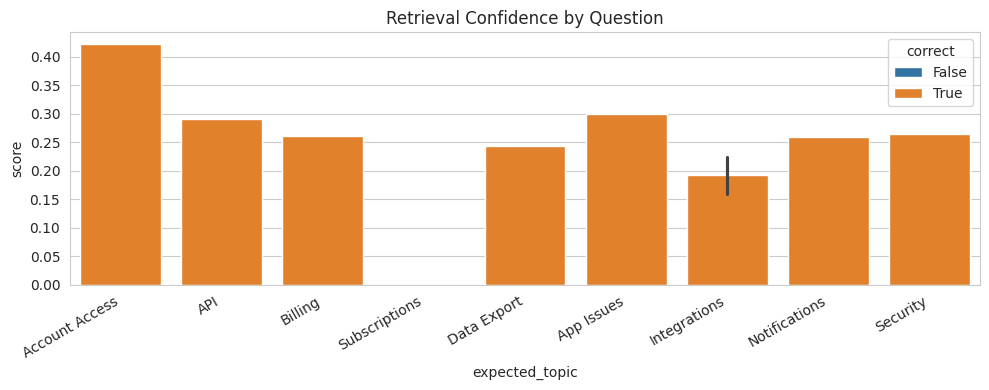

In [41]:
eval_set = pd.DataFrame([
    {"question": "How do I reset my password?", "expected_topic": "Account Access"},
    {"question": "What does 429 mean in the API?", "expected_topic": "API"},
    {"question": "How long do refunds take?", "expected_topic": "Billing"},
    {"question": "Can I cancel a monthly plan anytime?", "expected_topic": "Subscriptions"},
    {"question": "How do I export data as JSON?", "expected_topic": "Data Export"},
    {"question": "Why does the app crash on my phone?", "expected_topic": "App Issues"},
    {"question": "How do webhooks work?", "expected_topic": "Integrations"},
    {"question": "What if my email notifications do not arrive?", "expected_topic": "Notifications"},
    {"question": "How secure is customer data?", "expected_topic": "Security"},
    {"question": "Where can I find invoices?", "expected_topic": "Billing"},
    {"question": "How do I change notification preferences?", "expected_topic": "Notifications"},
    {"question": "What happens if a webhook fails?", "expected_topic": "Integrations"},
])

predicted_topics = []
top_scores = []
top3_hit = []

for q, expected in zip(eval_set["question"], eval_set["expected_topic"]):
    retrieved = retrieve_chunks(q, top_k=TOP_K_CONTEXT)

    if retrieved is None:
        predicted_topics.append("No Result")
        top_scores.append(0.0)
        top3_hit.append(False)
        continue

    predicted_topics.append(retrieved.iloc[0]["topic"])
    top_scores.append(float(retrieved.iloc[0]["score"]))
    top3_hit.append(expected in retrieved["topic"].tolist())

eval_set["predicted_topic"] = predicted_topics
eval_set["score"] = top_scores
eval_set["top3_hit"] = top3_hit
eval_set["correct"] = eval_set["expected_topic"] == eval_set["predicted_topic"]

display(eval_set)

retrieval_accuracy = eval_set["correct"].mean()
retrieval_top3 = eval_set["top3_hit"].mean()

print(f"Top-1 retrieval accuracy: {retrieval_accuracy:.2%}")
print(f"Top-3 retrieval hit rate: {retrieval_top3:.2%}")

plt.figure(figsize=(10, 4))
sns.barplot(data=eval_set, x="expected_topic", y="score", hue="correct", dodge=False)
plt.xticks(rotation=30, ha="right")
plt.title("Retrieval Confidence by Question")
plt.tight_layout()
plt.show()

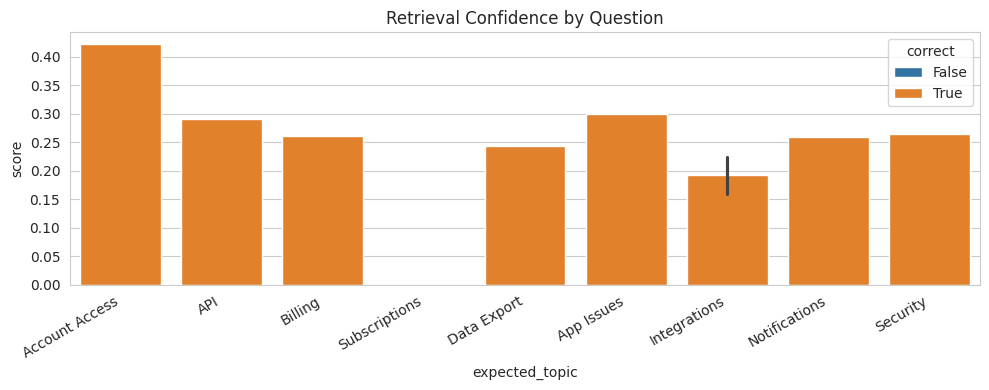

In [42]:
plt.figure(figsize=(10, 4))
sns.barplot(data=eval_set, x="expected_topic", y="score", hue="correct", dodge=False)
plt.xticks(rotation=30, ha="right")
plt.title("Retrieval Confidence by Question")
plt.tight_layout()
plt.show()

## Step 10: Real-World Style Questions
These simulate practical user interactions.

In [43]:
real_questions = [
    "I was charged twice last month. What should I do?",
    "My webhook stopped sending payloads after yesterday.",
    "The mobile app is very slow and sometimes freezes.",
    "Can I use single sign-on for the enterprise plan?",
    "How do I change notification emails?"
]

evaluation_rows = []

for q in real_questions:

    answer, retrieved = generate_answer(q)

    top_topic = (
        retrieved.iloc[0]["topic"]
        if retrieved is not None and len(retrieved) > 0
        else "No Retrieval"
    )

    evaluation_rows.append({
        "Question": q,
        "Retrieved Topic": top_topic,
        "Answer Preview": answer[:120]
    })

    print("\nQUESTION:", q)
    print("ANSWER:", answer)

    if retrieved is not None:
        display(retrieved[["title", "topic", "score"]])

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)


QUESTION: I was charged twice last month. What should I do?
ANSWER: I could not find that information in the knowledge base.

QUESTION: My webhook stopped sending payloads after yesterday.
ANSWER: [Source: Chunk: 9_1 [Source: Backups, and Importing Data]

Sources: Slack, Webhooks, and Third-Party Tools, Escalation Paths and Response Times, Exports, Backups, and Importing Data


,title,topic,score
0,"Slack, Webhooks, and Third-Party Tools",Integrations,0.158944
1,Escalation Paths and Response Times,Support,0.000000
2,"Exports, Backups, and Importing Data",Data Export,0.000000



QUESTION: The mobile app is very slow and sometimes freezes.
ANSWER: [Source: Chunk: 9_1 [Source: Backups, and Importing Data]

Sources: Crashes, Performance, and Compatibility, Email and Push Notification Settings, Exports, Backups, and Importing Data


,title,topic,score
0,"Crashes, Performance, and Compatibility",App Issues,0.291536
1,Email and Push Notification Settings,Notifications,0.103885
2,"Exports, Backups, and Importing Data",Data Export,0.000000



QUESTION: Can I use single sign-on for the enterprise plan?
ANSWER: Password Reset and Login Lockout

Sources: Privacy, Encryption, and Data Retention, Plans, Upgrades, and Cancellations, Password Reset and Login Lockouts


,title,topic,score
0,"Privacy, Encryption, and Data Retention",Security,0.197616
1,"Plans, Upgrades, and Cancellations",Subscriptions,0.045655
2,Password Reset and Login Lockouts,Account Access,0.040633



QUESTION: How do I change notification emails?
ANSWER: [Source: Chunk: Data Export | Chunk: 9_1 Exports, Backups, and Importing Data]

Sources: Email and Push Notification Settings, Escalation Paths and Response Times, Exports, Backups, and Importing Data


,title,topic,score
0,Email and Push Notification Settings,Notifications,0.397388
1,Escalation Paths and Response Times,Support,0.000000
2,"Exports, Backups, and Importing Data",Data Export,0.000000


,Question,Retrieved Topic,Answer Preview
0,I was charged twice last month. What should I do?,No Retrieval,I could not find that information in the knowl...
1,My webhook stopped sending payloads after yest...,Integrations,"[Source: Chunk: 9_1 [Source: Backups, and Impo..."
2,The mobile app is very slow and sometimes free...,App Issues,"[Source: Chunk: 9_1 [Source: Backups, and Impo..."
3,Can I use single sign-on for the enterprise plan?,Security,Password Reset and Login Lockout\n\nSources: P...
4,How do I change notification emails?,Notifications,[Source: Chunk: Data Export | Chunk: 9_1 Expor...


## Step 11: Save Artifacts
We save the corpus, vectorizer, matrix, and configuration so the project can be reused.

In [44]:
artifact_dir = OUTPUT_DIR / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

kb_df.to_csv(artifact_dir / "knowledge_base.csv", index=False)
chunks_df.to_csv(artifact_dir / "chunks.csv", index=False)
joblib.dump(vectorizer, artifact_dir / "tfidf_vectorizer.joblib")
joblib.dump(doc_matrix, artifact_dir / "tfidf_matrix.joblib")

with open(artifact_dir / "config.json", "w") as f:
    json.dump({
        "model_name": MODEL_NAME,
        "top_k_context": TOP_K_CONTEXT,
        "memory_turns": MEMORY_TURNS,
        "max_new_tokens": MAX_NEW_TOKENS,
        "seed": SEED
    }, f, indent=2)

print("Artifacts saved to:", artifact_dir)

Artifacts saved to: /kaggle/working/context_aware_rag_chatbot/artifacts


## Step 12: Create a Streamlit App
The notebook writes a ready-to-run `streamlit_app.py` file for deployment.

In [45]:
streamlit_code = r'''
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import torch
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

BASE_DIR = Path(__file__).parent / "artifacts"
MODEL_NAME = "google/flan-t5-small"
TOP_K_CONTEXT = 3
MEMORY_TURNS = 4
MAX_NEW_TOKENS = 128
MIN_SIMILARITY = 0.15
ABSTAIN_MESSAGE = "I could not find that information in the knowledge base."

@st.cache_resource
def load_resources():
    chunks_df = pd.read_csv(BASE_DIR / "chunks.csv")
    vectorizer = joblib.load(BASE_DIR / "tfidf_vectorizer.joblib")
    doc_matrix = joblib.load(BASE_DIR / "tfidf_matrix.joblib")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    return chunks_df, vectorizer, doc_matrix, tokenizer, model, device

chunks_df, vectorizer, doc_matrix, tokenizer, model, device = load_resources()

if "history" not in st.session_state:
    st.session_state.history = []

def format_history(history, max_turns=MEMORY_TURNS):
    if not history:
        return "No prior context."
    recent = history[-2 * max_turns:]
    lines = []
    for msg in recent:
        role = "User" if msg["role"] == "user" else "Assistant"
        lines.append(f"{role}: {msg['content']}")
    return "\\n".join(lines)

def retrieve_chunks(query, top_k=TOP_K_CONTEXT, min_similarity=MIN_SIMILARITY):
    query_vec = vectorizer.transform([query])
    sims = cosine_similarity(query_vec, doc_matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    top_score = float(sims[top_idx[0]]) if len(top_idx) > 0 else 0.0

    if top_score < min_similarity:
        return None

    results = chunks_df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results.reset_index(drop=True)

def build_prompt(question, history_text, retrieved_df):
    context_blocks = []
    for _, row in retrieved_df.iterrows():
        context_blocks.append(
            f"[Source: {row['title']} | Topic: {row['topic']} | Chunk: {row['chunk_id']}]\\n{row['chunk_text']}"
        )
    context_text = "\\n\\n".join(context_blocks)

    return f"""
You are a retrieval-grounded support assistant.

STRICT RULES:
- Answer ONLY using the retrieved knowledge base context and the conversation history.
- Do NOT use outside knowledge.
- If the answer is not explicitly present, say: "I could not find that information in the knowledge base."
- Be concise, factual, and helpful.
- Do not invent policies, numbers, or details.

Conversation history:
{history_text}

Retrieved context:
{context_text}

User question:
{question}

Grounded answer:
""".strip()

@torch.no_grad()
def answer_question(question):
    history_text = format_history(st.session_state.history)
    retrieved = retrieve_chunks(question, top_k=TOP_K_CONTEXT)

    if retrieved is None:
        return ABSTAIN_MESSAGE, None

    prompt = build_prompt(question, history_text, retrieved)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

    output_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        num_beams=4,
        early_stopping=True
    )

    answer = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    if not answer:
        answer = ABSTAIN_MESSAGE

    sources = ", ".join(retrieved["title"].dropna().unique().tolist())
    answer = f"{answer}\\n\\nSources: {sources}"

    return answer, retrieved

st.title("Context-Aware RAG Chatbot")
st.caption("Ask questions about the knowledge base. The assistant retrieves relevant chunks and uses conversation history.")

if st.button("Clear chat"):
    st.session_state.history = []
    st.rerun()

user_input = st.chat_input("Type your question...")

if user_input:
    answer, retrieved = answer_question(user_input)
    st.session_state.history.append({"role": "user", "content": user_input})
    st.session_state.history.append({"role": "assistant", "content": answer})

for msg in st.session_state.history:
    with st.chat_message(msg["role"]):
        st.write(msg["content"])

if st.session_state.history:
    st.subheader("Most recent retrieval results")
    last_user = st.session_state.history[-2]["content"] if len(st.session_state.history) >= 2 else st.session_state.history[-1]["content"]
    retrieved_now = retrieve_chunks(last_user, top_k=TOP_K_CONTEXT)
    if retrieved_now is not None:
        st.dataframe(retrieved_now[["title", "topic", "score"]])
    else:
        st.info("No sufficiently relevant context was found for the latest question.")
'''


In [46]:
app_path = OUTPUT_DIR / "streamlit_app.py"

app_path.write_text(
    streamlit_code,
    encoding="utf-8"
)

print("Streamlit app saved to:", app_path)

Streamlit app saved to: /kaggle/working/context_aware_rag_chatbot/streamlit_app.py


## Final Summary
- The chatbot uses a custom corpus and a retrieval layer.
- Conversation memory is preserved across turns.
- Answers are grounded in retrieved knowledge chunks.
- The notebook saves reusable artifacts and generates a Streamlit deployment file.